In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.__version__

'2.5.2'

In [ ]:
np.random.seed(42)

x = np.random.random()
print(x)

coin_flips = np.random.choice(["орёл", "решка"], size=10)
print("Результаты бросков монеты:", coin_flips)

dice_roll = np.random.randint(0, 7, size=10)
print("Результаты бросков кубика:", dice_roll)

0.3745401188473625
Результаты бросков монеты: ['орёл' 'орёл' 'орёл' 'решка' 'орёл' 'орёл' 'орёл' 'решка' 'орёл' 'орёл']
Результаты бросков кубика:  [2 2 4 3 2 5 4 1 3 5]


### Что изменится в результатах, если убрать строку np.random.seed(42)?  
- Результаты при повторных запусках будут отличаться
### Почему в np.random.randint(1, 7, ...) верхняя граница равна именно 7, а не 6, ведь кубик имеет только 6 граней?  
- Потому что верхняя граница не входит в диапазон значений `np.random.randint`

n=1: эмпирическая P(орёл) = 0.0000
n=10: эмпирическая P(орёл) = 0.6000
n=100: эмпирическая P(орёл) = 0.4900
n=1000: эмпирическая P(орёл) = 0.5080
n=10000: эмпирическая P(орёл) = 0.5016
n=100000: эмпирическая P(орёл) = 0.4970
n=1000000: эмпирическая P(орёл) = 0.5003
n=10000000: эмпирическая P(орёл) = 0.5000


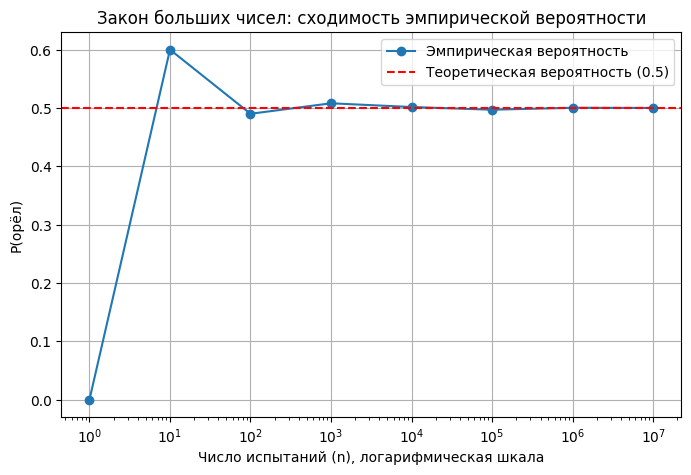

In [14]:
sample_sizes = [10**i for i in range(8)]
empirical_probs = []

for n in sample_sizes:
    flips = np.random.choice([0,1], size=n)
    p_empirical = np.mean(flips)
    empirical_probs.append(p_empirical)
    print(f"n={n}: эмпирическая P(орёл) = {p_empirical:.4f}")

# Построение графика сходимости
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, empirical_probs, marker='o', label='Эмпирическая вероятность')
plt.axhline(y=0.5, color='red', linestyle='--', label='Теоретическая вероятность (0.5)')
plt.xscale('log')
plt.xlabel('Число испытаний (n), логарифмическая шкала')
plt.ylabel('P(орёл)')
plt.title('Закон больших чисел: сходимость эмпирической вероятности')
plt.legend()
plt.grid(True)


### Почему при малых n (например, n=10) эмпирическая вероятность может сильно отличаться от 0,5, а при больших n (например, n=100000) — почти совпадает с ним? Сформулируйте ответ своими словами, опираясь на закон больших чисел.
- Чем больше испытаний проводится, тем ближе результат к среднему значению

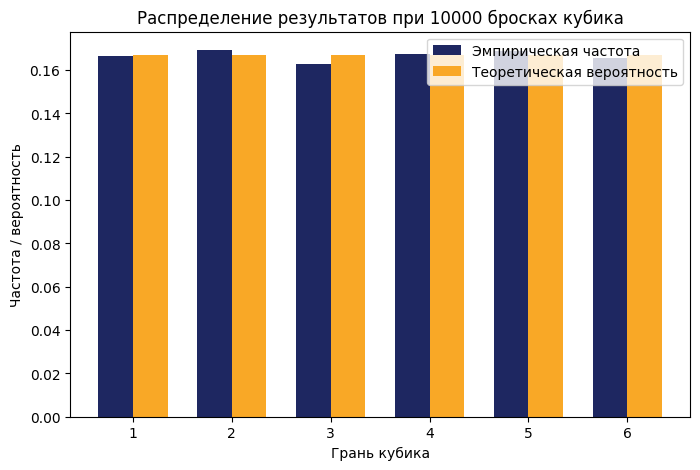

Эмпирические частоты: [0.1665 0.1692 0.1625 0.1672 0.1689 0.1657]


In [15]:
np.random.seed(42)
 
N = 10000
rolls = np.random.randint(1, 7, size=N)
 
# Подсчёт числа выпадений каждой грани (1..6)
counts = np.bincount(rolls)[1:]         # элемент [0] отбрасываем - значения "0" на кубике нет
empirical_freqs = counts / N        # переведите counts в доли (частоты)
 
theoretical_freqs = np.full(6, 1/6)     # теоретическая вероятность каждой грани = 1/6
 
# Построение столбчатой диаграммы
faces = np.arange(1, 7)
width = 0.35
 
plt.figure(figsize=(8, 5))
plt.bar(faces - width/2, empirical_freqs, width, label='Эмпирическая частота', color='#1E2761')
plt.bar(faces + width/2, theoretical_freqs, width, label='Теоретическая вероятность', color='#F9A826')
plt.xlabel('Грань кубика')
plt.ylabel('Частота / вероятность')
plt.title(f'Распределение результатов при {N} бросках кубика')
plt.xticks(faces)
plt.legend()
plt.show()
 
print("Эмпирические частоты:", np.round(empirical_freqs, 4))


### Насколько сильно эмпирические частоты отличаются от теоретической вероятности 1/6 ≈ 0,1667? Как вы думаете, что произойдёт с этим отличием, если увеличить N до 1 000 000?
- Эмпирические частоты не сильно отличаются от теоритической вероятности. Если увеличить число экспирементов, то отличие будет ещё меньше.

In [16]:
# Выборочные (эмпирические) характеристики
sample_mean = np.mean(rolls)
sample_var  = np.var(rolls)
 
# Теоретические характеристики для равномерного распределения на {1,...,6}
# E[X] = (1+2+3+4+5+6) / 6
theoretical_mean = (1+2+3+4+5+6) / 6
 
# D[X] = E[(X - E[X])^2], вычислите как среднее квадратов отклонений от 3.5
values = np.arange(1, 7)
theoretical_var = np.mean((values - theoretical_mean) ** 2)
 
print(f"Выборочное среднее:        {sample_mean:.4f}   |  Теоретическое: {theoretical_mean:.4f}")
print(f"Выборочная дисперсия:      {sample_var:.4f}   |  Теоретическая: {theoretical_var:.4f}")


Выборочное среднее:        3.4999   |  Теоретическое: 3.5000
Выборочная дисперсия:      2.9194   |  Теоретическая: 2.9167


Совпадают ли выборочные и теоретические значения точно? Если нет — почему, ведь мы использовали целых 10 000 испытаний? | Они совпадают с точностью до 2 знаков после запятой. Довольно точно

Оценка π методом Монте-Карло: 3.14412
Истинное значение π (np.pi): 3.14159
Абсолютная ошибка: 0.00253


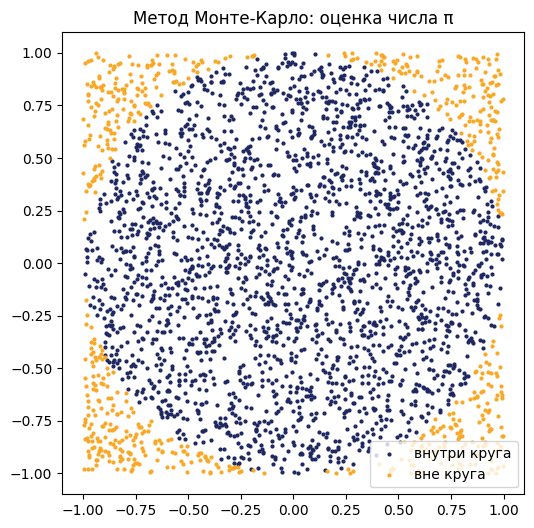

In [17]:
import numpy as np
import matplotlib.pyplot as plt
 
np.random.seed(42)
 
N = 100000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
 
inside = (x**2 + y**2) <= 1        # булев массив: True, если точка внутри круга
 
pi_estimate = 4 * np.sum(inside) / N
 
print(f"Оценка π методом Монте-Карло: {pi_estimate:.5f}")
print(f"Истинное значение π (np.pi): {np.pi:.5f}")
print(f"Абсолютная ошибка: {abs(pi_estimate - np.pi):.5f}")
 
# Визуализация (для наглядности возьмём только первые 3000 точек)
plt.figure(figsize=(6, 6))
plt.scatter(x[:3000][inside[:3000]], y[:3000][inside[:3000]], s=4, color='#1E2761', label='внутри круга')
plt.scatter(x[:3000][~inside[:3000]], y[:3000][~inside[:3000]], s=4, color='#F9A826', label='вне круга')
plt.gca().set_aspect('equal')
plt.legend()
plt.title('Метод Монте-Карло: оценка числа π')
plt.show()
